# LHS/Sobol'-FMQAによる初期学習データ生成

LHS/Sobol'-FMQAは，ブラックボックス最適化手法であるfactorization machine with quadratic-optimization annealing（FMQA）の初期学習データ生成を改良する手法である．本チュートリアルでは，Latin hypercube sampling（LHS）またはSobol'準ランダム列を用いて，FMQAの初期学習データを生成する．

元の`LHS-FMA.py`および`Sobol-FMA.py`と同様に，連続空間上で初期サンプルを生成してブラックボックス関数の出力値を取得した後，離散化およびone-hotエンコーディングを行う．

対象論文：[Improving FMQA via Initial Training Data Design Considering Marginal Bit Coverage in One-Hot Encoding](https://arxiv.org/abs/2605.04825)

## 背景

FMQAでは，初期学習データセットにおいてone-hotエンコーディング後の一部のビットが一度も活性化されず，そのビットに対応するFMのパラメータを十分に学習できない場合がある．

## 手法の目的

LHSまたはSobol'準ランダム列を用いて空間充填性の高い初期サンプルを生成し，one-hotエンコーディング後の周辺ビット被覆を改善することで，FMの初期学習データセットを適切に構築する．

## LHS/Sobol'-FMQAの手順

1. LHSまたはSobol'準ランダム列を用いて，$[0, 1)$上の連続値を生成する．
2. 各変数の定義域へスケーリングし，初期サンプル$x^{(d)}$を得る．
3. ブラックボックス関数の出力値$y^{(d)} = f(x^{(d)})$を得る．
4. 同じ初期サンプルを離散化し，one-hotエンコーディング後の周辺ビット被覆を確認する．
5. 初期学習データセット$\mathcal{D}^{(0)} = \{(x^{(d)}, y^{(d)})\}$を構築し，FMQAを実行する．

## ライブラリの使用方法

### 計算環境の準備

repositoryをcloneした環境で，次のコマンドを実行して必要ライブラリをインストールする．

```bash
uv sync
```

Fixstars Amplify AEを用いてFMQAまで実行する場合は，ABCI-QなどのAmplify AEへ接続できる計算環境が必要である．初期サンプル生成，ブラックボックス関数の呼び出しおよび周辺ビット被覆の確認には，Amplify AEへの接続は不要である．

In [1]:
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
from amplify import FixstarsClient
from amplify_bbopt import DiscretizationSpec, RealVariable, blackbox

from amplify_bbopt_ext.initial_sampling import (
    lhs_initial_samples,
    marginal_coverage,
    sobol_initial_samples,
    warn_if_incomplete_marginal_coverage,
)

### パラメータ設定

主な変更箇所は次のセルである．Sobol'準ランダム列では任意の正の初期学習データ数を指定できるが，balance特性を保つため，`n_init_data = 2**m`を推奨する．2のべき乗でない場合も処理は停止せず，警告を表示して指定された初期サンプル数を生成する．

In [2]:
# ===== 利用者が変更する設定 =====
n_variables = 2
bounds = (-3.0, 3.0)
n_bins = 32
sampling_method = "sobol"  # "lhs" または "sobol"
n_init_data = 32
seed = 42
scramble = True

# Amplify AEへ接続できる環境でFMQAまで実行する場合のみTrueにする．
run_fmqa = False

lower_bounds = np.full(n_variables, bounds[0])
upper_bounds = np.full(n_variables, bounds[1])

### ブラックボックス関数の設定

本チュートリアルでは，ブラックボックス関数のベンチマークとしてRastrigin関数を用いる．`initial_data`に格納された連続値をブラックボックス関数へ入力し，その出力値を取得する．`RealVariable`の離散化設定は，FMQAにおける入力値のエンコーディングに使用される．

In [3]:
disc_spec = DiscretizationSpec(num_bins=n_bins)
x_list = [
    RealVariable(bounds, discretization_spec=disc_spec)
    for _ in range(n_variables)
]


def rastrigin(x: list[float] | np.ndarray) -> float:
    x_array = np.asarray(x, dtype=float)
    return float(
        10 * x_array.size
        + np.sum(x_array**2 - 10 * np.cos(2 * np.pi * x_array))
    )


@blackbox
def bb_func(input_x: list[float] = x_list) -> float:  # type: ignore
    return rastrigin(input_x)

### 初期サンプル生成

LHSまたはSobol'準ランダム列を用いて，初期学習データのための解を生成する．返り値は配列形状`(n_init_data, n_variables)`の連続値であり，離散候補値またはone-hotベクトルではない．

In [4]:
if sampling_method == "lhs":
    initial_data = lhs_initial_samples(
        lower_bounds,
        upper_bounds,
        n_init_data,
        seed=seed,
    )
elif sampling_method == "sobol":
    initial_data = sobol_initial_samples(
        lower_bounds,
        upper_bounds,
        n_init_data,
        seed=seed,
        scramble=scramble,
    )
else:
    raise ValueError("sampling_method must be 'lhs' or 'sobol'")

print(f"初期学習データの配列形状: {initial_data.shape}")
print(f"各変数の最小値: {initial_data.min(axis=0)}")
print(f"各変数の最大値: {initial_data.max(axis=0)}")
initial_data[:5]

初期学習データの配列形状: (32, 2)
各変数の最小値: [-2.95727852 -2.83128108]
各変数の最大値: [2.83836193 2.83082039]


array([[-1.76881145,  0.97504785],
       [ 0.99814554, -2.59526609],
       [ 2.23399519,  2.27785952],
       [-1.47064776, -0.89221947],
       [-0.09086845,  1.98141883]])

### ブラックボックス関数の呼び出し

各初期サンプル$x^{(d)}$について，ブラックボックス関数の出力値$y^{(d)} = f(x^{(d)})$を取得する．`initial_data`と`initial_objectives`は，元コードの`scaled_vals_init`と`y_init`にそれぞれ対応する．

In [5]:
initial_objectives = np.array([rastrigin(x) for x in initial_data])
print(f"初期学習データにおける目的関数の最良値: {initial_objectives.min():.6f}")
initial_objectives[:5]

初期学習データにおける目的関数の最良値: 5.588436


array([13.02285111, 25.99377627, 30.91700057, 24.99600656,  5.58843634])

### 周辺ビット被覆の確認

連続値を`n_bins`個の等幅区間へ離散化する．これは，元コードにおける`np.digitize`を用いた処理に対応する．初期学習データセットが完全な周辺ビット被覆を満たさない場合も処理は停止せず，警告を表示して処理を継続する．

In [6]:
bin_edges = np.linspace(bounds[0], bounds[1], n_bins + 1)
discrete_indices = np.clip(
    np.digitize(initial_data, bin_edges) - 1,
    0,
    n_bins - 1,
)
bin_values = [np.arange(n_bins) for _ in range(n_variables)]

coverage = warn_if_incomplete_marginal_coverage(discrete_indices, bin_values)
print(f"完全な周辺ビット被覆: {coverage.is_complete}")
print(f"各変数の未被覆ビット数: {[len(values) for values in coverage.missing]}")

完全な周辺ビット被覆: True
各変数の未被覆ビット数: [0, 0]


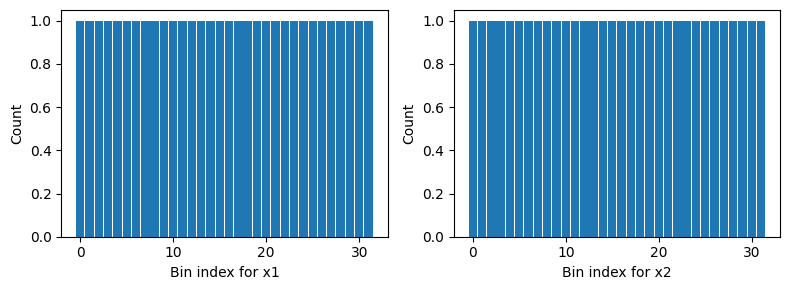

In [7]:
fig, axes = plt.subplots(
    1,
    n_variables,
    figsize=(4 * n_variables, 3),
    squeeze=False,
)
for index in range(n_variables):
    axes[0, index].hist(
        discrete_indices[:, index],
        bins=np.arange(n_bins + 1) - 0.5,
        rwidth=0.9,
    )
    axes[0, index].set_xlabel(f"Bin index for x{index + 1}")
    axes[0, index].set_ylabel("Count")
plt.tight_layout()

### FMQAの実行

Fixstars Amplify AEへ接続できる計算環境でFMQAまで実行する場合は，パラメータ設定セルの`run_fmqa`を`True`に変更する．既定値の`False`では，FMQAの実行のみをスキップする．

`LatestDatasetOptimizer`は初期学習データの入力値を内部でエンコーディングするため，本チュートリアル内でone-hotベクトルを構築する必要はない．

In [8]:
result = None
if run_fmqa:
    from amplify_bbopt_ext.latest_filter import run

    client = FixstarsClient()
    client.url = "http://localhost:1080"
    client.parameters.timeout = timedelta(milliseconds=1000)
    client.parameters.num_gpus = 4

    result = run(
        client=client,
        bb_func=bb_func,
        size_limit=200,
        k=8,
        n_iter=50,
        initial_data=initial_data,
        epochs=1000,
        optimizer_params={"lr": 0.01},
    )
    print(result.best.values)
    print(result.best.objective)
else:
    print("FMQAの実行をスキップした．Amplify AE環境ではrun_fmqa=Trueに設定する．")

FMQAの実行をスキップした．Amplify AE環境ではrun_fmqa=Trueに設定する．


## 結果の可視化

初期学習データにおけるブラックボックス関数の出力値の推移を表示する．FMQAを実行した場合は，`result.training_data`および`result.history`から最適化プロセスの履歴を取得できる．

/Users/hayashitaiga/ABCI-Q_amplifybbopt/amplify-bbopt-ext/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hayashitaiga/ABCI-Q_amplifybbopt/amplify-bbopt-ext/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hayashitaiga/ABCI-Q_amplifybbopt/amplify-bbopt-ext/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 35413 (\N{CJK UNIFIED IDEOGRAPH-8A55}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hayashitaiga/ABCI-Q_amplifybbopt/amplify-bbopt-ext/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hayashitaiga/ABCI-Q_amplifybbopt/amplify-bbopt-ex

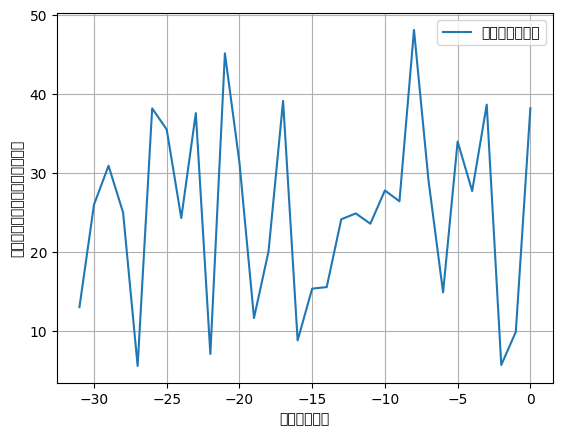

In [9]:
plt.plot(
    range(-n_init_data + 1, 1),
    initial_objectives,
    color="tab:blue",
    label="初期学習データ",
)
plt.xlabel("初期評価回数")
plt.ylabel("ブラックボックス関数の出力値")
plt.grid(True)
plt.legend()

## パラメータ設定のTips

- `n_init_data`：初期学習データ数を表す．値を大きくすると周辺ビット被覆を満たしやすくなる一方で，ブラックボックス関数の呼び出し回数が増加する．
- Sobol'準ランダム列では任意の正の`n_init_data`を指定できるが，balance特性を保つため2のべき乗を推奨する．
- `scramble=True`：scramblingを有効にする．`seed`を固定することで初期サンプルを再現できる．
- LHSとSobol'準ランダム列を比較する場合は，ブラックボックス関数，変数の定義域，離散点数，初期学習データ数，FMのハイパーパラメータおよび試行回数を揃える．
- 離散変数またはカテゴリ変数を直接扱う場合は，`map_unit_samples_to_discrete`を用いて，単位超立方体上の点を各変数の候補値へ写像する．

## LHS/Sobol'-FMQAの引用

```bibtex
@article{hayashi2026initialdata,
  title={Improving FMQA via Initial Training Data Design Considering Marginal Bit Coverage in One-Hot Encoding},
  author={Hayashi, Taiga and Seki, Yuya and Terada, Kotaro and Mukasa, Yosuke and Kikuchi, Shuta and Tanaka, Shu},
  journal={arXiv preprint arXiv:2605.04825},
  year={2026}
}
```